for discussion, refer to:  
https://www.kaggle.com/competitions/biohub-cell-tracking-during-development/discussion/740145  
https://www.kaggle.com/competitions/biohub-cell-tracking-during-development/discussion/738217   

This model is trained without Kaggle annotations. It just uses focus-3D instance segmentation centroids + augmentation to simulate cell movement. It only uses frame from t=0,5,10 ..., i.e. 20% of kaggle data.

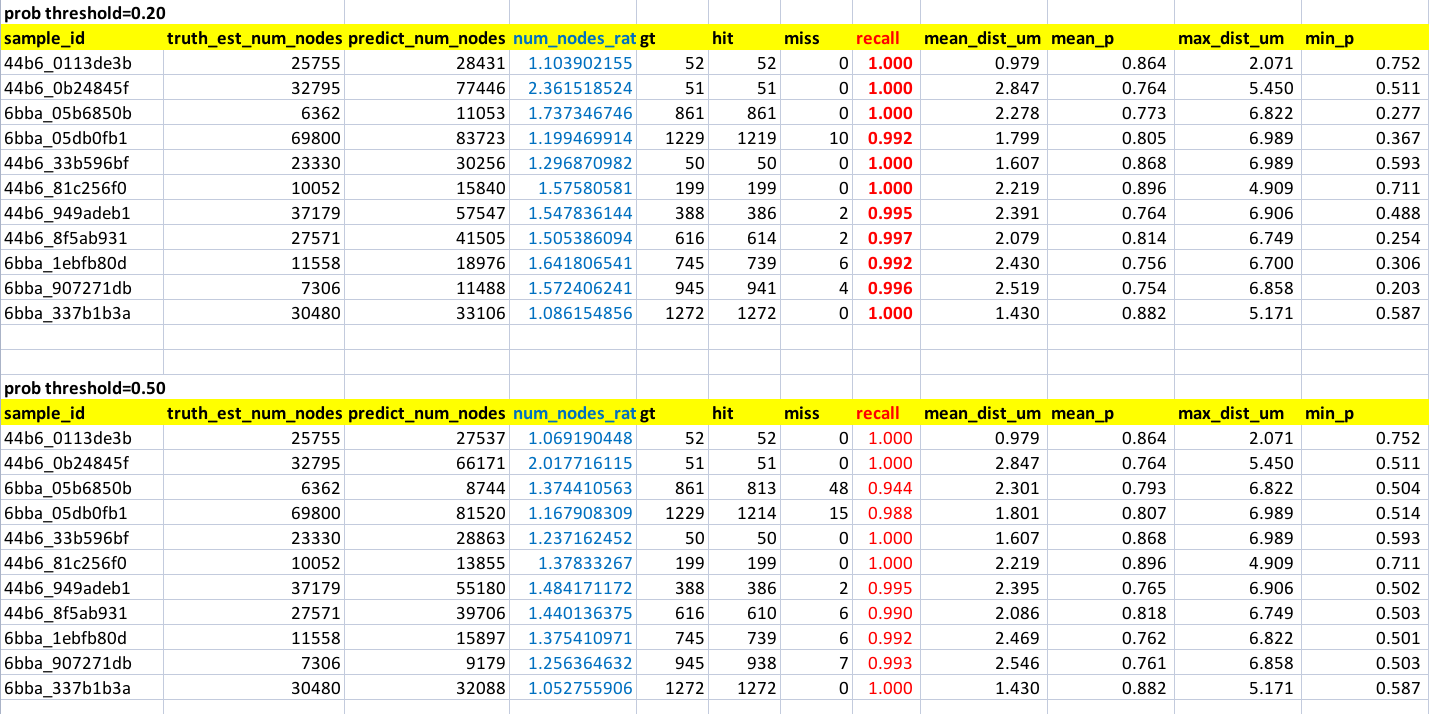

In [1]:
try:
    import zarr, geff, tracksdata

except: 
    import os
    import sys
    import subprocess
    import importlib
    import importlib.util
    from pathlib import Path
    
    # Polars wheel in the support package uses the 32-bit runtime package.
    os.environ.setdefault("POLARS_PREFER_PKG", "32")
    
    SUPPORT_DIR = Path(
        "/kaggle/input/datasets/pilkwang/biohub-tracking-support-pack-50ep-v1"
    )
    WHEELS_DIR = SUPPORT_DIR / "wheels"
    
    if not WHEELS_DIR.exists():
        # Fallback for Kaggle's shorter mounted dataset path.
        candidates = list(Path("/kaggle/input").glob("**/wheels"))
        if not candidates:
            raise FileNotFoundError("Could not find the attached offline wheels directory")
        WHEELS_DIR = candidates[0]
    
    print("Offline wheels:", WHEELS_DIR)
    
    
    # These are packages supplied by the attached dataset.
    # Deliberately exclude:
    #   numpy, scipy, torch, pandas, dask, xarray, numba, llvmlite
    #
    # Kaggle already supplies compatible versions of those packages.
    OFFLINE_PACKAGES = [
        "tracksdata",
        "zarr==3.2.1",
        "numcodecs==0.15.1",
        "donfig==0.8.1.post1",
        "geff==1.2.0.1.1",
        "geff-spec==1.1.1",
        "pyscipopt==6.2.1",
        "ilpy==0.6.0",
        "rustworkx==0.18.0",
        "polars==1.42.0",
        "polars-runtime-32==1.42.0",
        "bidict==0.23.1",
        "imagecodecs==2026.6.26",
    ]
    
    
    def module_missing(module_name: str) -> bool:
        return importlib.util.find_spec(module_name) is None
    
    
    # Import name differs from pip package name in several cases.
    REQUIRED_IMPORTS = {
        "tracksdata": "tracksdata",
        "zarr": "zarr",
        "numcodecs": "numcodecs",
        "geff": "geff",
        "pyscipopt": "pyscipopt",
        "ilpy": "ilpy",
        "rustworkx": "rustworkx",
        "polars": "polars",
        "imagecodecs": "imagecodecs",
    }
    
    
    def purge_modules(module_roots):
        """
        Remove already-imported package modules from sys.modules.
    
        Normally this cell runs before imports, but this also protects against
        accidental imports performed by earlier Kaggle initialization code.
        """
        for root in module_roots:
            for name in list(sys.modules):
                if name == root or name.startswith(root + "."):
                    sys.modules.pop(name, None)
    
    
    def install_offline_packages():
        cmd = [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--no-index",
            "--no-deps",
            "--find-links",
            str(WHEELS_DIR),
            *OFFLINE_PACKAGES,
        ]
    
        print("Installing attached packages without modifying NumPy/SciPy/Torch...")
        result = subprocess.run(
            cmd,
            text=True,
            capture_output=True,
        )
    
        if result.returncode != 0:
            print(result.stdout[-4000:])
            print(result.stderr[-4000:])
            raise RuntimeError("Offline dependency installation failed")
    
        purge_modules(REQUIRED_IMPORTS.values())
    
    
    install_offline_packages()
    
    
    # Verify the complete import chain needed by biohub_tracking.io.
    failures = {}
    
    for name, module_name in {
        **REQUIRED_IMPORTS,
        "numpy": "numpy",
        "scipy": "scipy",
        "dask": "dask.array",
        "xarray": "xarray",
    }.items():
        try:
            importlib.import_module(module_name)
        except Exception as exc:
            failures[name] = f"{type(exc).__name__}: {exc}"
    
    if failures:
        raise ImportError(
            "Dependency verification failed:\n"
            + "\n".join(f"{name}: {error}" for name, error in failures.items())
        )

import zarr, geff, tracksdata
print("All offline dependencies imported successfully.")

#-----------------------------------------------------------------------------------------
import sys
sys.path.append("/kaggle/input/datasets/hengck23/hengck23-cell-point-detector-demo")
sys.path.append("/kaggle/input/datasets/pilkwang/biohub-tracking-support-pack-50ep-v1/repo/src")
#import biohub_tracking as tracking_cellmot


import tracksdata as td
import os
import time
import polars as pl
import numpy as np
import pandas as pd
import zarr
from geff import GeffMetadata
from biohub_tracking.io import open_dataset, save_graph
from biohub_tracking.metrics import evaluate, node_recall

import torch
from model_v12 import *


print("import ok!!!")

Offline wheels: /kaggle/input/datasets/pilkwang/biohub-tracking-support-pack-50ep-v1/wheels
Installing attached packages without modifying NumPy/SciPy/Torch...


/usr/local/lib/python3.12/dist-packages/dask/array/image.py:7: FutureWarning: `find_available_plugins` is deprecated since version 0.25 and will be removed in version 0.27. The plugin infrastructure of `skimage.io` is deprecated. Instead, use `imageio` or other I/O packages directly.
  from skimage.io import imread as sk_imread
/usr/lib/python3.12/importlib/__init__.py:90: FutureWarning: `reset_plugins` is deprecated since version 0.25 and will be removed in version 0.27. The plugin infrastructure of `skimage.io` is deprecated. Instead, use `imageio` or other I/O packages directly.
  return _bootstrap._gcd_import(name[level:], package, level)


All offline dependencies imported successfully.
import ok!!!


In [2]:
# processing tricks

# todo: do nms using refine or node logit?
# add_cluster: duplicate-node clustering / greedy NMS
@torch.no_grad()
def cluster_predicted_nodes(out, radius=1.0):
    """
    Greedy score-ordered duplicate suppression on refined node coordinates.

    For each frame:
      1) sort valid predictions by refine_logit descending;
      2) keep the highest-scoring remaining prediction;
      3) suppress remaining predictions within `radius`;
      4) compact kept nodes to IDs 0..K-1.

    We keep an actual model prediction rather than averaging coordinates/features,
    so node_feature and refine_zyx remain mutually consistent.
    """
    if radius is None or radius <= 0:
        n = int(out.mask.sum().item())
        return out, {"num_before": n, "num_after": n, "num_removed": 0}

    B, N, _ = out.refine_zyx.shape
    device = out.refine_zyx.device

    new_refine_zyx = torch.zeros_like(out.refine_zyx)
    new_refine_logit = torch.zeros_like(out.refine_logit)
    new_peak_zyx = torch.zeros_like(out.peak_zyx)
    new_peak_logit = torch.zeros_like(out.peak_logit)
    new_mask = torch.zeros_like(out.mask)
    new_node_feature = [torch.zeros_like(f) for f in out.node_feature]

    new_count = []
    num_before = 0
    num_after = 0
    r2 = float(radius) ** 2

    for b in range(B):
        valid = torch.where(out.mask[b])[0]
        nv = int(len(valid))
        num_before += nv

        if nv == 0:
            new_count.append(0)
            continue

        zyx = out.refine_zyx[b, valid].float()
        score = out.refine_logit[b, valid].float()
        order = torch.argsort(score, descending=True)

        suppressed = torch.zeros(nv, dtype=torch.bool, device=device)
        keep_local = []

        for j in order.tolist():
            if bool(suppressed[j]):
                continue

            keep_local.append(j)
            d2 = ((zyx - zyx[j]) ** 2).sum(dim=-1)
            suppressed |= d2 <= r2

        keep_local = torch.as_tensor(keep_local, dtype=torch.long, device=device)
        keep = valid[keep_local]
        k = int(len(keep))

        num_after += k
        new_count.append(k)
        new_mask[b, :k] = True
        new_refine_zyx[b, :k] = out.refine_zyx[b, keep]
        new_refine_logit[b, :k] = out.refine_logit[b, keep]
        new_peak_zyx[b, :k] = out.peak_zyx[b, keep]
        new_peak_logit[b, :k] = out.peak_logit[b, keep]

        for level, f in enumerate(out.node_feature):
            new_node_feature[level][b, :k] = f[b, keep]

    out.refine_zyx = new_refine_zyx
    out.refine_logit = new_refine_logit
    out.peak_zyx = new_peak_zyx
    out.peak_logit = new_peak_logit
    out.node_feature = new_node_feature
    out.mask = new_mask
    out.count = new_count
    return out

def edge_top_cumulative_bidirectional(
    edge_logit,
    mask_src,
    mask_dst,
    t_start,
    no_link_logit=0.0,
    cumulative=0.99,
    no_link_weight=1.0,
):
    """
    Bidirectional version of edge_top_cumulative.

    edge_logit : (B, Ns, Nd)
        Raw pairwise edge logits.

    For each real edge i -> j:
        p_dst(j | i) = softmax over destination
        p_src(i | j) = softmax over source

        score(i, j) = p_dst(j | i) * p_src(i | j)

    NO_LINK exists only on the forward/source->destination side:
        score(i, NO_LINK) = p_dst(NO_LINK | i) * no_link_weight

    Scores are then normalized over destinations for each source so that
    cumulative probability selection remains meaningful.

    Returns list of dict:
        t
        src_id
        dst_id       (-1 = NO_LINK)
        prob
        rank
        cumulative_prob
        logit
        prob_dst
        prob_src
    """

    edge_logit = edge_logit.float()
    mask_src = mask_src.bool()
    mask_dst = mask_dst.bool()

    B, Ns, Nd = edge_logit.shape
    rows = []

    for b in range(B):
        # -------------------------------------------------------------
        # Real edge logits
        # -------------------------------------------------------------
        real_logits = edge_logit[b]  # (Ns, Nd)

        # -------------------------------------------------------------
        # Forward probability P(dst | src)
        # Includes explicit NO_LINK.
        # -------------------------------------------------------------
        dst_logits = real_logits.masked_fill(~mask_dst[b][None, :], -1e9)

        no_link = torch.full(
            (Ns, 1),
            float(no_link_logit),
            dtype=dst_logits.dtype,
            device=dst_logits.device,
        )

        dst_logits_with_no_link = torch.cat([dst_logits, no_link], dim=-1)
        prob_dst = torch.softmax(dst_logits_with_no_link, dim=-1)  # (Ns, Nd+1)

        # -------------------------------------------------------------
        # Reverse probability P(src | dst)
        # Only real edges participate.
        # -------------------------------------------------------------
        src_logits = real_logits.masked_fill(~mask_src[b][:, None], -1e9)
        src_logits = src_logits.masked_fill(~mask_dst[b][None, :], -1e9)

        prob_src = torch.softmax(src_logits, dim=0)  # (Ns, Nd)

        # Invalid destinations should contribute exactly zero.
        prob_src = prob_src * mask_dst[b][None, :].to(prob_src.dtype)

        # -------------------------------------------------------------
        # Bidirectional edge score
        # -------------------------------------------------------------
        score_real = prob_dst[:, :Nd] * prob_src

        score_no_link = prob_dst[:, Nd:Nd + 1] * float(no_link_weight)

        score = torch.cat([score_real, score_no_link], dim=-1)

        # Normalize again over destination so each row sums to one.
        prob = score / score.sum(dim=-1, keepdim=True).clamp_min(1e-12)

        # -------------------------------------------------------------
        # Cumulative candidate selection
        # -------------------------------------------------------------
        src_ids = torch.where(mask_src[b])[0]

        for src_id in src_ids.tolist():
            p = prob[src_id]

            p_sorted, idx_sorted = torch.sort(p, descending=True)
            cum = torch.cumsum(p_sorted, dim=0)

            hit = torch.where(cum >= cumulative)[0]
            if len(hit):
                n_keep = int(hit[0]) + 1
            else:
                n_keep = len(p_sorted)

            # if USE_ILP:
            #     n_keep = max(n_keep, 2)

            for rank in range(n_keep):
                idx = int(idx_sorted[rank])

                if idx == Nd:
                    dst_id = -1
                    p_src_value = 1.0
                    raw_logit = float(no_link_logit)
                else:
                    dst_id = idx
                    p_src_value = float(prob_src[src_id, idx])
                    raw_logit = float(real_logits[src_id, idx])

                rows.append({
                    "t": int(t_start + b),
                    "src_id": int(src_id),
                    "dst_id": dst_id,
                    "rank": rank,
                    "prob": float(p_sorted[rank]),
                    "cumulative_prob": float(cum[rank]),
                    "logit": raw_logit,
                    "prob_dst": float(prob_dst[src_id, idx]),
                    "prob_src": p_src_value,
                })

    return rows

def select_top1_with_dst_correction(predict_edge_df):
    """
    Keep forward top-1, then resolve destination conflicts using original logits.

    For each conflicting (t, dst_id):
      - Softmax over sources whose forward top-1 selected this destination.
      - Keep the source with maximum probability.
      - No birth option is added in this experiment.

    Non-conflicting edges stay unchanged. Original prob/rank are preserved.
    NO_LINK rows are excluded from the returned graph.
    """
    required = {"t", "src_id", "dst_id", "rank", "prob", "logit"}
    missing = required - set(predict_edge_df.columns)
    if missing:
        raise ValueError(f"Missing columns: {sorted(missing)}")

    df = predict_edge_df[
        (predict_edge_df["rank"] == 0) & (predict_edge_df["dst_id"] >= 0)
    ].copy()
    df = df.drop_duplicates(["t", "src_id", "dst_id"]).reset_index(drop=True)

    if df.groupby(["t", "src_id"]).size().gt(1).any():
        raise ValueError("Input contains multiple distinct rank-0 edges for one source")

    if not np.isfinite(df["logit"].to_numpy(dtype=np.float64)).all():
        raise ValueError("Selected edge logits must be finite")

    keys = ["t", "dst_id"]
    groups = df.groupby(keys, sort=False)
    df["dst_num_competing_src"] = groups["src_id"].transform("size")

    # Stable softmax over competing sources for each destination.
    score = df["logit"].astype(np.float64)
    weight = np.exp(score - groups["logit"].transform("max"))
    denominator = weight.groupby([df["t"], df["dst_id"]]).transform("sum")
    df["dst_competition_prob"] = weight / denominator

    # Softmax preserves logit ordering; source ID breaks exact ties deterministically.
    df = df.sort_values(
        ["t", "dst_id", "logit", "src_id"], ascending=[True, True, False, True],
        kind="stable",
    )
    df = df.drop_duplicates(keys, keep="first")
    return df.sort_values(["t", "src_id"], kind="stable").reset_index(drop=True)



####################################################################################3
# Kaggle GEFF writer / official metric helper
def prediction_to_geff_graph(predict_node_df, predict_edge_df, downsample=(1, 4, 4)):
    """
    Convert our per-frame local node IDs and directed t->t+1 edges into a
    tracksdata graph suitable for save_graph(... .geff).

    predict_node_df columns:
        t, node_id, z, y, x, p

    predict_edge_df columns:
        t, src_id, dst_id, ...

    src_id/dst_id are LOCAL node IDs inside frame t / t+1, so the key
    (t, node_id) is used to map them to graph-global node IDs.

    Our inference coordinates are on the downsampled 64^3 grid.  Kaggle's
    truth GEFF uses the original image voxel coordinate system, therefore
    coordinates are multiplied by downsample=(1,4,4) before saving.
    """
    required_node = {"t", "node_id", "z", "y", "x"}
    required_edge = {"t", "src_id", "dst_id"}
    missing_node = required_node - set(predict_node_df.columns)
    missing_edge = required_edge - set(predict_edge_df.columns)
    if missing_node:
        raise ValueError(f"predict_node_df missing columns: {sorted(missing_node)}")
    if missing_edge:
        raise ValueError(f"predict_edge_df missing columns: {sorted(missing_edge)}")

    graph = td.graph.InMemoryGraph()
    for key in ["z", "y", "x"]:
        graph.add_node_attr_key(key, pl.Float64, -999999.0)

    dz, dy, dx = map(float, downsample)

    node_records = []
    local_keys = []
    for r in predict_node_df.itertuples(index=False):
        node_records.append({
            "t": int(r.t),
            "z": float(r.z) * dz,
            "y": float(r.y) * dy,
            "x": float(r.x) * dx,
        })
        local_keys.append((int(r.t), int(r.node_id)))

    graph_node_ids = graph.bulk_add_nodes(node_records)
    node_map = {
        key: int(graph_id)
        for key, graph_id in zip(local_keys, graph_node_ids)
    }

    edge_records = []
    skipped_edges = 0

    # Optional attributes are useful for inspection but are not required
    # by the Kaggle evaluator.
    graph.add_edge_attr_key("edge_prob", pl.Float64, 0.0)

    for r in predict_edge_df.itertuples(index=False):
        t = int(r.t)
        src_key = (t, int(r.src_id))
        dst_key = (t + 1, int(r.dst_id))

        src = node_map.get(src_key)
        dst = node_map.get(dst_key)
        if src is None or dst is None:
            skipped_edges += 1
            continue

        prob = float(getattr(r, "prob", 1.0))
        edge_records.append({
            "source_id": src,
            "target_id": dst,
            "edge_prob": prob,
        })

    if edge_records:
        graph.bulk_add_edges(edge_records)

    return graph, skipped_edges


print("helper ok!!!")

helper ok!!!


In [3]:
#load model ----------------------------------------
CFG = DotDict(
    unet_cfg=DotDict(
        channel=(64, 128, 256),
        dropout=0.1,
        gradient_checkpointing=True,

        node_peak_kernel=3,
        node_peak_threshold=0.2,
        max_detected_nodes=1024,
    ),
    tx_cfg=DotDict(
        feat_dims=(64, 128, 256),
        hidden_dim=256,
        embed_dim=128,
        n_heads=4,
        n_layers=4,
        dropout=0.1,
    ),
)
DEVICE = "cuda"

CHECKPOINT = f"/kaggle/input/datasets/hengck23/hengck23-cell-point-detector-demo/00000008.pth"
model = End2EndCellLinker(CFG).to(DEVICE)
model = model.eval()
saved = torch.load( CHECKPOINT,map_location=DEVICE,weights_only=False)
print( "load model:", model.load_state_dict(saved["model_state_dict"]))



#load data ----------------------------------------
KAGGLE_DIR = "/kaggle/input/competitions/biohub-cell-tracking-during-development"
valid_id = \
    ['44b6_0113de3b', '44b6_0b24845f', '6bba_05b6850b', '6bba_05db0fb1', '44b6_33b596bf', '44b6_81c256f0', '44b6_949adeb1', '44b6_8f5ab931', '6bba_1ebfb80d', '6bba_907271db', '6bba_337b1b3a']


def load_one_for_infer(sample_id):
    zarr_file = f"{KAGGLE_DIR}/train/{sample_id}.zarr"

    ds = open_dataset(
        zarr_file,
        normalize=False,
        load_image=False,
        require_tracks=True,
    )
    q_low  = float(ds.quantiles["0.001"])
    q_high = float(ds.quantiles["0.999"])
    image  = zarr.open_group(str(ds.zarr_path), mode="r")["0"]
    volume = image[:, ::1, ::4, ::4].astype(np.float32)
    volume = (volume - q_low) / (q_high - q_low + 1e-6)
    volume = np.clip(volume, 0.0, None).astype(np.float32)
    track = ds.tracks
    kaggle_node_df = track.node_attrs().to_pandas()  # ['node_id', 't', 'y', 'z', 'x']
    kaggle_edge_df = track.edge_attrs().to_pandas()  # ['edge_id', 'source_id', 'target_id']

    #tracks_data, lineage = ds.napari_tracks()
    #kaggle_track_df = tracks_data.to_pandas()

    geff_meta = GeffMetadata.read(zarr_file.replace(".zarr", ".geff"))
    est_num_nodes = float(geff_meta.extra["estimated_number_of_nodes"])
    meta = {
        "est_num_nodes": est_num_nodes,
        "downsample": [1, 4, 4],
        "um_per_voxel": [1.625, 1.625, 1.625],
       # "lineage":lineage,
    }
    return volume, meta, kaggle_node_df, kaggle_edge_df

###########################################################################
#start here


#start here
dump_dir = './dump'
os.makedirs(dump_dir, exist_ok=True)

for i, sample_id in enumerate(valid_id):
    start_time = time.time()
    print("process:", i, sample_id, "-----------------------")
    volume, meta, kaggle_node_df, kaggle_edge_df = load_one_for_infer(sample_id)

    predict_edge_df = []
    predict_node_df = []

    num_frame = 100
    step = 20
    for t in range(0, num_frame - 1, step):
        t_end = min(t + step + 1, num_frame)
        vol = torch.from_numpy(volume[t:t_end]).to(DEVICE).unsqueeze(1)

        with torch.no_grad():
            with torch.amp.autocast("cuda", dtype=torch.float16):
                # todo: augmentation

                Z, Y, X = 64, 64, 64
                out = model.unet(vol)
                out = cluster_predicted_nodes(out, radius=3.0)
                node_prob = torch.sigmoid(out.refine_logit)

                # ----------------

                out0 = DotDict(
                    pyr=[f[:-1] for f in out.pyr],
                    node_logit=out.node_logit[:-1],
                    refinement=out.refinement[:-1],
                    peak_zyx=out.peak_zyx[:-1],
                    peak_logit=out.peak_logit[:-1],
                    refine_zyx=out.refine_zyx[:-1],
                    refine_logit=out.refine_logit[:-1],
                    node_feature=[f[:-1] for f in out.node_feature],
                    mask=out.mask[:-1],
                    count=out.count[:-1],
                )
                out1 = DotDict(
                    pyr=[f[1:] for f in out.pyr],
                    node_logit=out.node_logit[1:],
                    refinement=out.refinement[1:],
                    peak_zyx=out.peak_zyx[1:],
                    peak_logit=out.peak_logit[1:],
                    refine_zyx=out.refine_zyx[1:],
                    refine_logit=out.refine_logit[1:],
                    node_feature=[f[1:] for f in out.node_feature],
                    mask=out.mask[1:],
                    count=out.count[1:],
                )
                out01 = model.linker(
                    out0.node_feature, out1.node_feature,
                    out0.refine_zyx, out1.refine_zyx,
                    out0.mask, out1.mask, (Z, Y, X),
                )
                edge_logit = out01.edge_logit

                # ------------------------------------------------------
                #save to predict_node_df
                first_b = 0 if t == 0 else 1
                for b in range(first_b, len(out.refine_zyx)):
                    t_b = t + b
                    ids = torch.where(out.mask[b])[0]

                    for node_id in ids.tolist():
                        z, y, x = out.refine_zyx[b, node_id].detach().float().cpu().tolist()

                        p = float(node_prob[b, node_id].detach().float().cpu())
                        predict_node_df.append({
                            "t": t_b,
                            "node_id": node_id,
                            "z": z,
                            "y": y,
                            "x": x,
                            "p": p,
                        })

                # ------------------------------------------------------
                # save to predict_edge_df. use cumulative-99% candidate list (include no link)
                rows = edge_top_cumulative_bidirectional(
                    edge_logit=edge_logit,
                    mask_src=out0.mask,
                    mask_dst=out1.mask,
                    t_start=t,
                    no_link_logit=0,
                    cumulative=0.99,
                )
                predict_edge_df.extend(rows)

                zz = 0
    predict_edge_df = pd.DataFrame(predict_edge_df)
    predict_edge_df.to_csv(f"{dump_dir}/predict_edge_df.{sample_id}.csv")
    predict_node_df = pd.DataFrame(predict_node_df)
    predict_edge_df = select_top1_with_dst_correction(predict_edge_df)
    predict_node_df.to_csv(f"{dump_dir}/predict_node_df.{sample_id}.csv")

    #save to kaggle format
    pred_graph, skipped_geff_edges = prediction_to_geff_graph(
        predict_node_df,
        predict_edge_df,
        downsample=meta["downsample"],
    )
    predict_file = f"{dump_dir}/{sample_id}.geff"
    save_graph(pred_graph, predict_file)

    elapsed = (time.time() - start_time) / 60
    print(f"len(predict_node_df): {len(predict_node_df)}")
    print(f"elapsed {elapsed} min\n")


load model: <All keys matched successfully>
process: 0 44b6_0113de3b -----------------------
len(predict_node_df): 28189
elapsed 0.4135845979054769 min

process: 1 44b6_0b24845f -----------------------
len(predict_node_df): 67961
elapsed 0.8265171607335409 min

process: 2 6bba_05b6850b -----------------------
len(predict_node_df): 9695
elapsed 0.19658637841542562 min

process: 3 6bba_05db0fb1 -----------------------
len(predict_node_df): 82875
elapsed 0.9287359356880188 min

process: 4 44b6_33b596bf -----------------------
len(predict_node_df): 28260
elapsed 0.364160410563151 min

process: 5 44b6_81c256f0 -----------------------
len(predict_node_df): 13296
elapsed 0.22930153210957846 min

process: 6 44b6_949adeb1 -----------------------
len(predict_node_df): 54751
elapsed 0.6349208950996399 min

process: 7 44b6_8f5ab931 -----------------------
len(predict_node_df): 39190
elapsed 0.4674921274185181 min

process: 8 6bba_1ebfb80d -----------------------
len(predict_node_df): 14839
elapsed

In [4]:
#evaluation here

summary_df = []
for i, sample_id in enumerate(valid_id):
    truth_file = f"{KAGGLE_DIR}/train/{sample_id}.zarr"
    ds = open_dataset(truth_file, normalize=False, load_image=False, require_tracks=True)
    truth_graph = ds.tracks
    # print(truth_graph)

    predict_file = f"{dump_dir}/{sample_id}.geff"
    pred_result = td.graph.IndexedRXGraph.from_geff(predict_file)
    pred_graph = pred_result[0]  # if isinstance(pred_result, tuple) else pred_result
    # print(pred_graph)

    print(sample_id, "---------------------------")
    er = evaluate(
        pred_graph,
        truth_graph,
        scale=ds.scale,
        max_distance=7.0,
    )
    print("edge TP:", er.edge_tp)
    print("edge FP:", er.edge_fp)
    print("edge FN:", er.edge_fn)
    print("division TP:", er.division_tp)
    print("division FP:", er.division_fp)
    print("division FN:", er.division_fn)

    edge_jaccard = (er.edge_tp )/(er.edge_tp + er.edge_fp + er.edge_fn)
    print("edge_jaccard:", edge_jaccard)

    recall = node_recall(pred_graph, truth_graph)
    print("node_recall:", recall)

    summary_df.append({
        "sample_id": sample_id,
        "node_recall": recall,
        "edge_jaccard": edge_jaccard,
        "edge_tp": er.edge_tp,
        "edge_fp": er.edge_fp,
        "edge_fn": er.edge_fn,
    })
summary_df = pd.DataFrame(summary_df)
print(summary_df)
print("edge_jaccard:", summary_df["edge_jaccard"].mean())
print("node_recall:",summary_df["node_recall"].mean())

44b6_0113de3b ---------------------------
edge TP: 50
edge FP: 0
edge FN: 0
division TP: 0
division FP: 0
division FN: 0
edge_jaccard: 1.0
node_recall: 1.0
44b6_0b24845f ---------------------------
edge TP: 42
edge FP: 8
edge FN: 7
division TP: 0
division FP: 0
division FN: 0
edge_jaccard: 0.7368421052631579
node_recall: 0.9803921568627451
6bba_05b6850b ---------------------------
edge TP: 836
edge FP: 14
edge FN: 9
division TP: 0
division FP: 0
division FN: 0
edge_jaccard: 0.9732246798603027
node_recall: 1.0
6bba_05db0fb1 ---------------------------
edge TP: 1105
edge FP: 82
edge FN: 78
division TP: 0
division FP: 0
division FN: 3
edge_jaccard: 0.8735177865612648
node_recall: 0.9910496338486574
44b6_33b596bf ---------------------------
edge TP: 48
edge FP: 1
edge FN: 1
division TP: 0
division FP: 0
division FN: 0
edge_jaccard: 0.96
node_recall: 1.0
44b6_81c256f0 ---------------------------
edge TP: 197
edge FP: 0
edge FN: 0
division TP: 0
division FP: 0
division FN: 0
edge_jaccard: 1.